<a href="https://colab.research.google.com/github/lsuvnt/heart-disease/blob/main/cardio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cardiovascular disease prediction with

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv('/content/cardio_train.csv', sep=';')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/cardio_train.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Check for Missing Values

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


### Handle Outliers and Incorrect Values

In [ ]:
# Convert 'age' from days to years
df['age_years'] = (df['age'] / 365.25).astype(int)

# Remove rows with invalid blood pressure values (ap_hi < ap_lo, or ap_hi/ap_lo being unrealistic)
# Based on medical understanding, ap_hi (systolic) should be greater than ap_lo (diastolic)
# Also, very low or very high values are likely data entry errors or extreme outliers
df = df[df['ap_lo'] < df['ap_hi']]
df = df[df['ap_hi'] > 0]
df = df[df['ap_lo'] > 0]

# Further filtering for reasonable blood pressure ranges (e.g., ap_hi between 60 and 250, ap_lo between 40 and 200)
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

# Check the new shape of the dataframe and describe again to see the impact
print(f"Shape after handling blood pressure outliers: {df.shape}")
df.describe()

Shape after handling blood pressure outliers: (68672, 14)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000
mean,49975.824019,19464.634087,1.348628,164.360860,74.118119,126.674132,81.307374,1.364661,1.225725,0.087969,0.053355,0.803355,0.494714,52.791676
std,28845.150013,2468.182600,0.476540,8.183657,14.331489,16.694859,9.454808,0.678893,0.571592,0.283252,0.224742,0.397464,0.499976,6.764942
min,0.000000,10798.000000,1.000000,55.000000,11.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000
25%,25002.750000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50012.500000,19701.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000
75%,74869.250000,21324.250000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000


### Separate Numerical and Categorical Features

In [ ]:
# 'id' column is not a feature for modeling
# 'age' (in days) is replaced by 'age_years'
# 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio' are categorical
# 'height', 'weight', 'ap_hi', 'ap_lo', 'age_years' are numerical

# Define numerical and categorical columns, excluding 'id' and 'age' (raw days)
numerical_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'] # 'cardio' is the target variable

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Display data types to confirm
df[numerical_cols + categorical_cols].info()

Numerical columns: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
Categorical columns: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
<class 'pandas.core.frame.DataFrame'>
Index: 68672 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age_years    68672 non-null  int64  
 1   height       68672 non-null  int64  
 2   weight       68672 non-null  float64
 3   ap_hi        68672 non-null  int64  
 4   ap_lo        68672 non-null  int64  
 5   gender       68672 non-null  int64  
 6   cholesterol  68672 non-null  int64  
 7   gluc         68672 non-null  int64  
 8   smoke        68672 non-null  int64  
 9   alco         68672 non-null  int64  
 10  active       68672 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 6.3 MB


### Normalize Numerical Features and Encode Categorical Features

In [ ]:
# Identify target variable
target = 'cardio'

# Define numerical and categorical features (excluding the target)
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the data
X = df.drop(columns=['id', 'age', target]) # Drop 'id' and original 'age' column
y = df[target]

X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(onehot_feature_names)

# Convert to DataFrame (optional, but good for inspection)
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("Shape of processed features:", X_processed_df.shape)
print("First 5 rows of processed features:")
print(X_processed_df.head())

Shape of processed features: (68672, 19)
First 5 rows of processed features:
   age_years    height    weight     ap_hi     ap_lo  gender_1  gender_2  \
0  -0.412671  0.444687 -0.845565 -0.998766 -0.138277       0.0       1.0   
1   0.326439 -1.021661  0.759304  0.798208  0.919393       1.0       0.0   
2  -0.264849  0.078100 -0.706011  0.199217 -1.195948       1.0       0.0   
3  -0.708315  0.566883  0.549973  1.397199  1.977064       0.0       1.0   
4  -0.856137 -1.021661 -1.264227 -1.597757 -2.253618       1.0       0.0   

   cholesterol_1  cholesterol_2  cholesterol_3  gluc_1  gluc_2  gluc_3  \
0            1.0            0.0            0.0     1.0     0.0     0.0   
1            0.0            0.0            1.0     1.0     0.0     0.0   
2            0.0            0.0            1.0     1.0     0.0     0.0   
3            1.0            0.0            0.0     1.0     0.0     0.0   
4            1.0            0.0            0.0     1.0     0.0     0.0   

   smoke_0  smoke_1  

### Check Class Imbalance

Class distribution for 'cardio':
cardio
0    34699
1    33973
Name: count, dtype: int64

Class percentages:
cardio
0    50.5286
1    49.4714
Name: proportion, dtype: float64


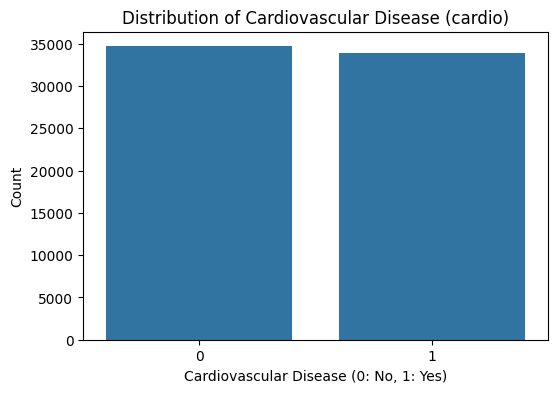

In [ ]:
# Check class imbalance for the target variable 'cardio'
class_counts = df['cardio'].value_counts()
class_percentages = df['cardio'].value_counts(normalize=True) * 100

print("Class distribution for 'cardio':")
print(class_counts)
print("\nClass percentages:")
print(class_percentages)

# Plotting the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df)
plt.title('Distribution of Cardiovascular Disease (cardio)')
plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

### Handle Outliers and Incorrect Values

In [ ]:
# Convert 'age' from days to years
df['age_years'] = (df['age'] / 365.25).astype(int)

# Remove rows with invalid blood pressure values (ap_hi < ap_lo, or ap_hi/ap_lo being unrealistic)
# Based on medical understanding, ap_hi (systolic) should be greater than ap_lo (diastolic)
# Also, very low or very high values are likely data entry errors or extreme outliers
df = df[df['ap_lo'] < df['ap_hi']]
df = df[df['ap_hi'] > 0]
df = df[df['ap_lo'] > 0]

# Further filtering for reasonable blood pressure ranges (e.g., ap_hi between 60 and 250, ap_lo between 40 and 200)
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

# Check the new shape of the dataframe and describe again to see the impact
print(f"Shape after handling blood pressure outliers: {df.shape}")
df.describe()

Shape after handling blood pressure outliers: (68672, 14)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000
mean,49975.824019,19464.634087,1.348628,164.360860,74.118119,126.674132,81.307374,1.364661,1.225725,0.087969,0.053355,0.803355,0.494714,52.791676
std,28845.150013,2468.182600,0.476540,8.183657,14.331489,16.694859,9.454808,0.678893,0.571592,0.283252,0.224742,0.397464,0.499976,6.764942
min,0.000000,10798.000000,1.000000,55.000000,11.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000
25%,25002.750000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50012.500000,19701.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000
75%,74869.250000,21324.250000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000


### Separate Numerical and Categorical Features

In [ ]:
# 'id' column is not a feature for modeling
# 'age' (in days) is replaced by 'age_years'
# 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio' are categorical
# 'height', 'weight', 'ap_hi', 'ap_lo', 'age_years' are numerical

# Define numerical and categorical columns, excluding 'id' and 'age' (raw days)
numerical_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'] # 'cardio' is the target variable

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Display data types to confirm
df[numerical_cols + categorical_cols].info()

Numerical columns: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
Categorical columns: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
<class 'pandas.core.frame.DataFrame'>
Index: 68672 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age_years    68672 non-null  int64  
 1   height       68672 non-null  int64  
 2   weight       68672 non-null  float64
 3   ap_hi        68672 non-null  int64  
 4   ap_lo        68672 non-null  int64  
 5   gender       68672 non-null  int64  
 6   cholesterol  68672 non-null  int64  
 7   gluc         68672 non-null  int64  
 8   smoke        68672 non-null  int64  
 9   alco         68672 non-null  int64  
 10  active       68672 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 6.3 MB


### Normalize Numerical Features and Encode Categorical Features

In [ ]:
# Identify target variable
target = 'cardio'

# Define numerical and categorical features (excluding the target)
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the data
X = df.drop(columns=['id', 'age', target]) # Drop 'id' and original 'age' column
y = df[target]

X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(onehot_feature_names)

# Convert to DataFrame (optional, but good for inspection)
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("Shape of processed features:", X_processed_df.shape)
print("First 5 rows of processed features:")
print(X_processed_df.head())

Shape of processed features: (68672, 19)
First 5 rows of processed features:
   age_years    height    weight     ap_hi     ap_lo  gender_1  gender_2  \
0  -0.412671  0.444687 -0.845565 -0.998766 -0.138277       0.0       1.0   
1   0.326439 -1.021661  0.759304  0.798208  0.919393       1.0       0.0   
2  -0.264849  0.078100 -0.706011  0.199217 -1.195948       1.0       0.0   
3  -0.708315  0.566883  0.549973  1.397199  1.977064       0.0       1.0   
4  -0.856137 -1.021661 -1.264227 -1.597757 -2.253618       1.0       0.0   

   cholesterol_1  cholesterol_2  cholesterol_3  gluc_1  gluc_2  gluc_3  \
0            1.0            0.0            0.0     1.0     0.0     0.0   
1            0.0            0.0            1.0     1.0     0.0     0.0   
2            0.0            0.0            1.0     1.0     0.0     0.0   
3            1.0            0.0            0.0     1.0     0.0     0.0   
4            1.0            0.0            0.0     1.0     0.0     0.0   

   smoke_0  smoke_1  

### Check Class Imbalance

Class distribution for 'cardio':
cardio
0    34699
1    33973
Name: count, dtype: int64

Class percentages:
cardio
0    50.5286
1    49.4714
Name: proportion, dtype: float64


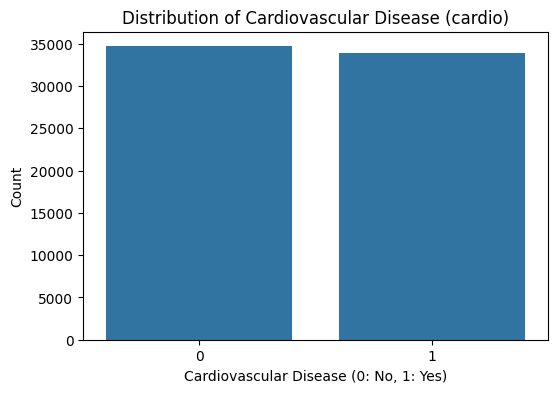

In [ ]:
# Check class imbalance for the target variable 'cardio'
class_counts = df['cardio'].value_counts()
class_percentages = df['cardio'].value_counts(normalize=True) * 100

print("Class distribution for 'cardio':")
print(class_counts)
print("\nClass percentages:")
print(class_percentages)

# Plotting the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df)
plt.title('Distribution of Cardiovascular Disease (cardio)')
plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()